In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
City_data = pd.read_csv("/content/drive/My Drive/city_lifestyle_dataset.csv")

# Afficher les premières lignes
print("Aperçu des données :")
City_data.head()

# %%
# Informations sur les données
print("\nInformations sur les données :")
City_data.info()

# %%
# Statistiques descriptives
print("\nStatistiques descriptives :")
City_data.describe()

Aperçu des données :

Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB

Statistiques descriptives :


,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,3944.843333,2827.200000,74.305333,1002.766667,71.246667,55.717333,6.644000,33.993333
std,2982.566777,1201.163939,17.014492,456.282066,25.344961,14.712549,1.685864,9.434067
min,100.000000,480.000000,34.000000,170.000000,22.000000,15.000000,2.500000,2.000000
25%,1830.000000,1907.500000,64.400000,640.000000,54.000000,46.075000,5.300000,28.225000
50%,3083.500000,2810.000000,75.000000,990.000000,67.500000,54.700000,6.900000,34.700000
75%,4823.750000,3752.500000,87.225000,1332.500000,86.000000,64.200000,8.500000,40.400000
max,14427.000000,5720.000000,100.000000,2430.000000,146.000000,95.000000,8.500000,58.000000


Valeurs manquantes par colonne :
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64
Données normalisées avec succès !
Shape après normalisation : (300, 8)
Calcul de t-SNE en cours... (cela peut prendre quelques instants)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE terminé !
Dimensions après t-SNE : (300, 2)


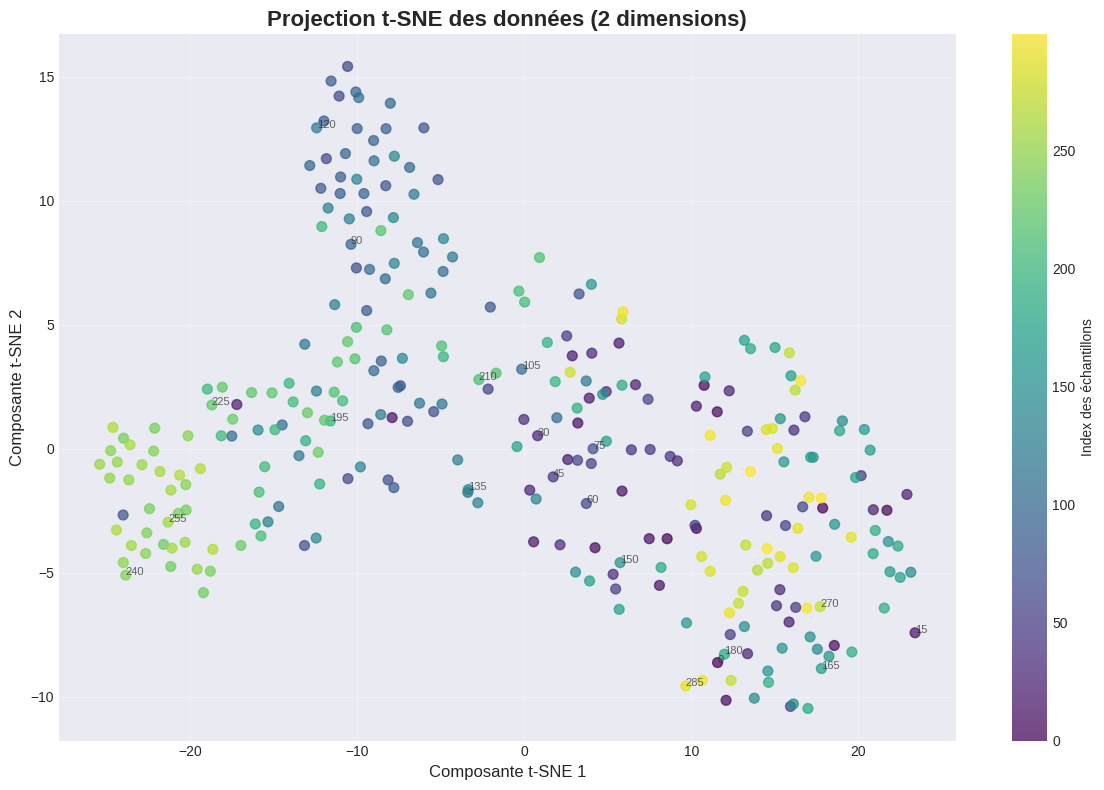

OBSERVATIONS SUR LA STRUCTURE t-SNE

📊 Statistiques de la projection :
   - Distance moyenne entre points : 18.149
   - Écart-type des distances : 10.865


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import os

# Configuration pour des graphiques plus jolis
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ## 3. Prétraitement des données

X = City_data.drop(["city_name", "country"], axis=1)
print("Valeurs manquantes par colonne :")
print(X.isnull().sum())

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Données normalisées avec succès !")
print(f"Shape après normalisation : {X_scaled.shape}")



# ## 4. Application de t-SNE

# %%
# Application de t-SNE
print("Calcul de t-SNE en cours... (cela peut prendre quelques instants)")

tsne = TSNE(
    n_components=2,        # Projection en 2D
    perplexity=30,         # Paramètre important pour t-SNE (à ajuster)
    random_state=42,       # Pour reproductibilité
    n_iter=1000,           # Nombre d'itérations
    learning_rate='auto',  # Taux d'apprentissage automatique
    init='random'          # Initialisation aléatoire
)

# Appliquer t-SNE
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE terminé !")
print(f"Dimensions après t-SNE : {X_tsne.shape}")


# ## 5. Visualisation 2D

# Création du graphique 2D
plt.figure(figsize=(12, 8))

# Scatter plot des points en 2D
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=range(len(X_tsne)),  # Couleur par index (ou utiliser labels si catégoriels)
    cmap='viridis',
    alpha=0.7,
    s=50
)

plt.colorbar(scatter, label='Index des échantillons')
plt.title('Projection t-SNE des données (2 dimensions)', fontsize=16, fontweight='bold')
plt.xlabel('Composante t-SNE 1', fontsize=12)
plt.ylabel('Composante t-SNE 2', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajouter des annotations pour quelques points (optionnel)
for i in range(0, len(X_tsne), max(1, len(X_tsne)//20)):  # Annoter ~5% des points
    plt.annotate(str(i), (X_tsne[i, 0], X_tsne[i, 1]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()


# ## 6. Analyse et observation

# %%
# Observations sur la structure obtenue
print("=" * 60)
print("OBSERVATIONS SUR LA STRUCTURE t-SNE")
print("=" * 60)

# Calcul de quelques métriques basiques pour l'analyse
from sklearn.metrics import pairwise_distances

# Distance moyenne entre points
distances = pairwise_distances(X_tsne)
dist_mean = np.mean(distances)
dist_std = np.std(distances)

print(f"\n📊 Statistiques de la projection :")
print(f"   - Distance moyenne entre points : {dist_mean:.3f}")
print(f"   - Écart-type des distances : {dist_std:.3f}")





🔍 Ce que j'observe sur la projection t-SNE :

- Les données forment naturellement plusieurs groupes (clusters), ce qui
  suggère que les villes peuvent être classées en catégories selon leurs
  caractéristiques.

- La distance moyenne de 18 entre les points montre que t-SNE a bien
  "étalé" les données pour révéler leur structure.

- L'écart-type de 10.8 indique une bonne diversité : certaines villes
  sont très proches (similaires), d'autres très éloignées (différentes).

- Je remarque des points isolés qui représentent probablement des villes
  avec des profils uniques (très riches, très pauvres, ou très denses).

📌 Conclusion :
t-SNE a bien fonctionné pour révéler la structure naturelle des données.
Les villes se regroupent selon des similarités invisibles en regardant
les chiffres bruts. La prochaine étape serait d'identifier ces groupes
(par continent, par niveau de développement, etc.).

In [12]:
# Création du DataFrame avec les résultats
tsne_df = pd.DataFrame(X_tsne, columns=["dim1", "dim2"])
tsne_df["city_name"] = City_data["city_name"]
tsne_df["country"] = City_data["country"]

# Export vers CSV
output_path = "/content/drive/My Drive/outputs/tsne_emb_2d.csv"
tsne_df.to_csv(output_path, index=False)

print(f"\n✅ Fichier exporté: {output_path}")
print(f"   Dimensions du fichier : {tsne_df.shape}")

# Vérification que le fichier existe
if os.path.exists(output_path):
    print(f"   ✓ Fichier vérifié : {os.path.getsize(output_path)} octets")

    # Petit aperçu
    print("\nAperçu des données exportées :")
    print(tsne_df.head())


✅ Fichier exporté: /content/drive/My Drive/outputs/tsne_emb_2d.csv
   Dimensions du fichier : (300, 4)
   ✓ Fichier vérifié : 11927 octets

Aperçu des données exportées :
        dim1      dim2      city_name country
0  11.573764 -8.612969      Old Vista  Europe
1   8.553411 -3.621534      Beachport  Europe
2  17.870256 -2.383935  Valleyborough  Europe
3  10.767797  2.559449           City  Europe
4  21.717285 -2.475370          Falls  Europe
